# 🌳 Where Are the Trees? — Mapping Vegetation (NDVI) Across CDMX

**Measuring green from space to find the second half of the urban-heat story.**

*Notebook 2 of 8 · Project: Dos Méxicos Bajo el Mismo Sol*  
*Author: Nelly Itzel Rodríguez Ortiz · Last updated: 4 June 2026*

Notebook 01 showed us that northern CDMX is up to **8 °C hotter** than the south. The first question anyone asks: *is it because there are fewer trees?* Today we answer that — by measuring green from space.

## 🔁 Quick recap from Notebook 01

In the previous notebook we used Landsat 8 and 9 to measure **Land Surface Temperature (LST)** across the ZMVM — the 16 alcaldías of CDMX plus the 60 EdoMex municipios that make up the metropolitan area. We found a **5–8 °C gap** between the northeast and the south, in both summer and winter.

> The southern mountains (Desierto de los Leones, the Ajusco, the Pedregal) stay cool and green. The urban north glows red.

## ❓ The first suspect: vegetation

That 5–8 °C gap is large enough to shape daily life. So what causes it? The first suspect is the most intuitive one: **vegetation**.

Trees and parks cool a city in two ways: they cast **shade**, and they release water from their leaves into the air, a process called **evapotranspiration**. Less vegetation means less of both, and therefore more heat.

In this notebook we measure that cooling capacity from space, using a satellite index called **NDVI**.

## 🌿 What is NDVI?

**NDVI = Normalized Difference Vegetation Index**

It is a single number, between **−1 and +1**, that measures "greenness" from space. The idea is simple: healthy plants reflect a lot of **near-infrared** light (NIR) and absorb **red** light to power photosynthesis. The ratio of those two signals is a near-perfect proxy for how much chlorophyll is out there.

| Surface | Typical NDVI |
|---|---|
| Dense forest, healthy woodland (Ajusco, Desierto de los Leones) | **0.6 – 0.9** |
| Urban parks, irrigated cropland (Chapultepec, Coyoacán plazas) | **0.4 – 0.6** |
| Residential streets with some trees | **0.2 – 0.4** |
| Dense urban, concrete, asphalt (Iztapalapa, GAM) | **0.05 – 0.2** |
| Water (lakes, reservoirs) | **less than 0** |

> 🌱 *If LST is the city's thermometer, NDVI is its chlorophyll detector.*

### 🎨 A note on the colors

The ColorBrewer YlGn palette progresses from pale yellow (arid, concrete surfaces) to dark blue (dense, healthy forest).

## 🗂️ Where the data comes from

| Step | Detail |
|---|---|
| **Satellite** | Landsat 8 and Landsat 9 (NASA–USGS) |
| **Product** | Collection 2, Level 2 (surface reflectance) |
| **Bands used** | SR_B4 (Red) and SR_B5 (Near-Infrared) |
| **Formula** | `NDVI = (NIR − Red) / (NIR + Red)` |
| **Time windows** | Summer 2025 (Jun–Aug) and Winter 2025–2026 (Dec–Feb) |
| **Cloud mask** | QA_PIXEL bits 3 (cloud) and 4 (shadow) |

All the heavy lifting (cloud masking, NDVI calculation, median compositing) is done by the `src/` package. This notebook focuses on **telling the story**.

### ⚙️ One-time setup

The first time you run this notebook, uncomment the `ee.Authenticate()` line and follow the browser prompt. After that, the kernel remembers you for the session.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # so `import src` works from any CWD

import ee
import geemap

from src import (
    CDMX_CENTER, CDMX_ZOOM, EE_PROJECT_ID, NDVI_VIS_PARAMS,
    get_norte_zmvm_aoi,
    get_periferia_zmvm_aoi,
    get_sur_zmvm_aoi,
    get_zmvm_municipalities_aoi,
    load_ndvi_composite,
)

# ee.Authenticate()  # ← uncomment the first time
ee.Initialize(project=EE_PROJECT_ID)
print("✅ Earth Engine ready")

/home/nells-it/Documentos/PERSONAL/Portafolio/Project1-IslasCalor/project1.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ Earth Engine ready


## 🔧 Building the map, step by step

The pipeline mirrors Notebook 01, but instead of temperature we measure "greenness":

1. **Collect** every clear-sky Landsat 8/9 image of the ZMVM for the season.
2. **Mask out the clouds** using the QA_PIXEL bitmask (bit 3 = cloud, bit 4 = shadow).
3. **Calculate NDVI** from the Red (SR_B4) and Near-Infrared (SR_B5) bands.
4. **Take the median** of all the clean images, to ignore stray readings the way the **house price in the middle of the street** ignores the one mansion that would skew an average.

The result: a single, clean vegetation map for the whole metropolitan area.

In [10]:
aoi = get_zmvm_municipalities_aoi()   # ZMVM: 16 CDMX alcaldías + 60 EdoMex municipios
print("AOI features:", aoi.size().getInfo())

AOI features: 76


In [11]:
ndvi_summer = load_ndvi_composite(
    aoi, start_date="2025-06-01", end_date="2025-09-01", cloud_max=20.0,
)
ndvi_winter = load_ndvi_composite(
    aoi, start_date="2025-12-01", end_date="2026-03-01", cloud_max=20.0,
)

print("Summer composite — band:", ndvi_summer.bandNames().getInfo())
print("Winter composite — band:", ndvi_winter.bandNames().getInfo())

Summer composite — band: ['NDVI']
Winter composite — band: ['NDVI']


## 🗺️ Three views of the city's vegetation

A single map at a single zoom level can hide as much as it reveals. To make the north-south divide impossible to miss, we look at the same NDVI composite at **three zoom levels**: the full metro area, then close-ups of the northern "concrete belt" and the southern "green privilege."

Each map reuses the `ndvi_summer` and `ndvi_winter` composites built above; the only thing that changes is the AOI and the zoom.

---

### Map 1 — The Big Picture: Full ZMVM

In [12]:
# Full ZMVM: 16 CDMX alcaldías + 60 EdoMex municipios = 76 features.
aoi_zmvm = get_zmvm_municipalities_aoi()

Map1 = geemap.Map(center=CDMX_CENTER, zoom=CDMX_ZOOM)

# Both seasons as toggleable raster layers.
Map1.addLayer(ndvi_summer, NDVI_VIS_PARAMS, "🌿 NDVI — Summer 2025 (Jun–Aug)")
Map1.addLayer(ndvi_winter, NDVI_VIS_PARAMS, "🌲 NDVI — Winter 2025–2026 (Dec–Feb)")

# ZMVM boundary and municipio outlines, color-coded by entidad.
Map1.addLayer(
    ee.Image().paint(aoi_zmvm, 0, 2), {"palette": ["black"]}, "ZMVM boundary",
)
cdmx_outline = aoi_zmvm.filter(ee.Filter.eq("entidad", "CDMX"))
edomex_outline = aoi_zmvm.filter(ee.Filter.eq("entidad", "EdoMex"))
Map1.addLayer(
    ee.Image().paint(cdmx_outline, 0, 1), {"palette": ["#ffffff"]},
    "CDMX municipio borders", False,
)
Map1.addLayer(
    ee.Image().paint(edomex_outline, 0, 1), {"palette": ["#ff7f00"]},
    "EdoMex municipio borders", False,
)

# Colorbar keyed to the summer layer.
Map1.add_colorbar(
    NDVI_VIS_PARAMS,
    label="NDVI (greenness, 0.1–0.8)",
    layer_name="🌿 NDVI — Summer 2025 (Jun–Aug)",
)
Map1.add_layer_control()
Map1

Map(center=[19.4326, -99.1332], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

> 🔍 **At this scale, the north-south vegetation divide is unmistakable.** Pale yellow stretches across the northern municipalities, while dark blues cluster in the southern mountains.

---

### Map 2 — The Concrete Belt: Northern CDMX and Its Periphery

In [5]:
# Northern periphery: 2 CDMX alcaldías + 4 EdoMex municipios = 6 features.
aoi_norte = get_norte_zmvm_aoi()

Map2 = geemap.Map(center=[19.49, -99.10], zoom=12)

# Summer NDVI only (no winter toggle in the close-ups).
Map2.addLayer(ndvi_summer, NDVI_VIS_PARAMS, "🌿 NDVI — Summer 2025 (Jun–Aug)")

# Municipio outlines and name labels.
Map2.addLayer(
    ee.Image().paint(aoi_norte, 0, 2), {"palette": ["black"]}, "Municipality borders",
)
Map2.add_labels(aoi_norte, "NOMGEO", font_size="11pt", font_color="black")

Map2.add_colorbar(
    NDVI_VIS_PARAMS,
    label="NDVI (greenness, 0.1–0.8)",
    layer_name="🌿 NDVI — Summer 2025 (Jun–Aug)",
)
Map2.add_layer_control()
Map2

Map(center=[19.49, -99.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

> 🔍 **This is ground zero.** Kilometer after kilometer of pale yellow — concrete, asphalt, and sparse vegetation. These are the same neighborhoods that were 5–8 °C hotter in Notebook 01.

---

### Map 3 — The Green Privilege: Southern CDMX and Its Forests

In [6]:
# Southern periphery: 6 CDMX alcaldías (Coyoacán, Álvaro Obregón, Tlalpan,
# La Magdalena Contreras, Cuajimalpa de Morelos, Xochimilco).
aoi_sur = get_sur_zmvm_aoi()

Map3 = geemap.Map(center=[19.30, -99.20], zoom=12)

# Summer NDVI only.
Map3.addLayer(ndvi_summer, NDVI_VIS_PARAMS, "🌿 NDVI — Summer 2025 (Jun–Aug)")

# Municipio outlines and name labels.
Map3.addLayer(
    ee.Image().paint(aoi_sur, 0, 2), {"palette": ["black"]}, "Municipality borders",
)
Map3.add_labels(aoi_sur, "NOMGEO", font_size="11pt", font_color="black")

Map3.add_colorbar(
    NDVI_VIS_PARAMS,
    label="NDVI (greenness, 0.1–0.8)",
    layer_name="🌿 NDVI — Summer 2025 (Jun–Aug)",
)
Map3.add_layer_control()
Map3

Map(center=[19.3, -99.2], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

> 🔍 **The south enjoys what the north lacks:** dark blues of dense tree cover, urban forests, and the cooling vegetation of the Ajusco mountains. This isn't an accident — it's the result of decades of unequal urban planning.

## ⚖️ A tale of two Mexicos: north vs south

We use the same municipio groups as Notebook 01:

- **Nororiente (hotter in LST):** Gustavo A. Madero, Iztapalapa, Ecatepec de Morelos, Tlalnepantla de Baz, Nezahualcóyotl
- **Sur (cooler in LST):** Coyoacán, Álvaro Obregón, Tlalpan, La Magdalena Contreras

If vegetation is part of the explanation for the temperature gap, we should see **higher mean NDVI in the south** than in the nororiente — in both seasons.

In [7]:
nororiente_names = [
    "Gustavo A. Madero", "Iztapalapa", "Ecatepec de Morelos",
    "Tlalnepantla de Baz", "Nezahualcóyotl",
]
sur_names = [
    "Coyoacán", "Álvaro Obregón", "Tlalpan", "La Magdalena Contreras",
]

nororiente = aoi.filter(ee.Filter.inList("NOMGEO", nororiente_names))
sur        = aoi.filter(ee.Filter.inList("NOMGEO", sur_names))

def mean_band(image, fc, band):
    return image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=fc.geometry().dissolve(),
        scale=30, maxPixels=1e9,
    ).getInfo()[band]

m_n_s = mean_band(ndvi_summer, nororiente, "NDVI")
m_s_s = mean_band(ndvi_summer, sur,        "NDVI")
m_n_w = mean_band(ndvi_winter, nororiente, "NDVI")
m_s_w = mean_band(ndvi_winter, sur,        "NDVI")

print(f"Summer  — North: {m_n_s:.3f}  |  South: {m_s_s:.3f}  |  Gap: {m_n_s - m_s_s:+.3f}")
print(f"Winter  — North: {m_n_w:.3f}  |  South: {m_s_w:.3f}  |  Gap: {m_n_w - m_s_w:+.3f}")

Summer  — North: 0.122  |  South: 0.233  |  Gap: -0.111
Winter  — North: 0.068  |  South: 0.163  |  Gap: -0.095


> 📊 **What the numbers show:** The nororiente's mean NDVI is barely above the "sparse vegetation" threshold (0.12 in summer, 0.07 in winter), while the south consistently sits in healthy vegetation territory (0.23 in summer, 0.16 in winter). The vegetation gap is **twice as large** in relative terms as the raw numbers suggest. And critically, **it does not close in winter** — meaning the north lacks vegetation year-round, not just during the dry season.

## 🔗 The LST–NDVI relationship at three scales

A single scatter plot can hide the geography. The strength of the LST–NDVI relationship changes depending on **where you look** — and that, more than the correlation itself, is what the rest of this project will lean on.

We sample the same NDVI-and-summer-LST relationship at three scales, each using 400 random points (seed=42, scale=120 m):

- **Scale 1 — The Concrete Belt:** CDMX + the 4 northern EdoMex municipios (GAM, Iztapalapa, Tlalnepantla, Naucalpan, Ecatepec, Nezahualcóyotl).
- **Scale 2 — The Green Privilege:** CDMX + the 6 southern alcaldías (Coyoacán, Álvaro Obregón, Tlalpan, La Magdalena Contreras, Cuajimalpa, Xochimilco).
- **Scale 3 — The Big Picture:** the full 76-municipio ZMVM.

Same data, same sample size, same regression — only the AOI changes. Each scale tells a different part of the story.

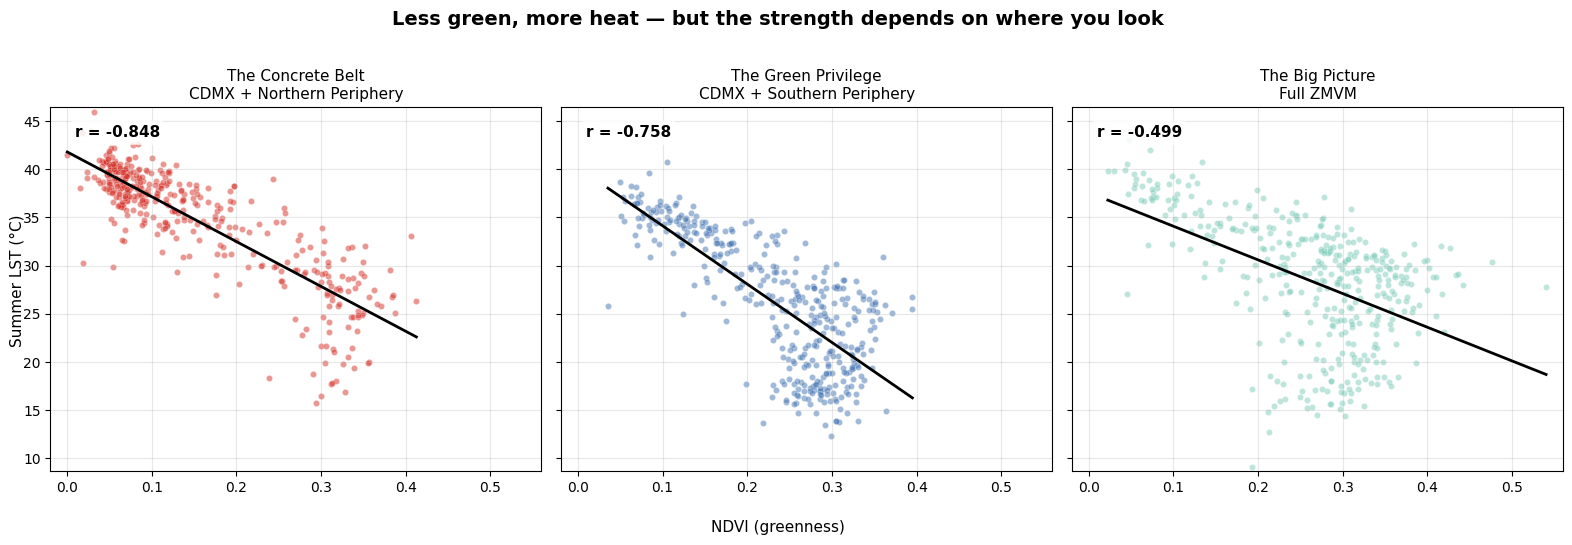


LST–NDVI Pearson r by scale:
  The Concrete Belt CDMX + Northern Periphery        r = -0.848
  The Green Privilege CDMX + Southern Periphery      r = -0.758
  The Big Picture Full ZMVM                          r = -0.499


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import load_lst_composite

# Reload BOTH NDVI and LST composites clipped to the full ZMVM so all three
# scales below have complete coverage. (The values inside the 20-municipio
# periferia are identical to the ndvi_summer loaded in code-03 and the
# lst_summer from the previous version of this cell.)
aoi_zmvm_full = get_zmvm_municipalities_aoi()
ndvi_summer_zmvm = load_ndvi_composite(
    aoi_zmvm_full, start_date="2025-06-01", end_date="2025-09-01", cloud_max=20.0,
)
lst_summer_zmvm = load_lst_composite(
    aoi_zmvm_full, start_date="2025-06-01", end_date="2025-09-01", cloud_max=20.0,
)

# Stack the two bands; pixels masked in either are dropped at sample time.
stacked = ndvi_summer_zmvm.addBands(lst_summer_zmvm.rename("LST_C"))

def sample_lst_ndvi(aoi, n=400, seed=42, scale=120):
    """Sample n random (NDVI, LST) pairs from the stacked image."""
    samples = stacked.sample(
        region=aoi.geometry(),
        scale=scale, numPixels=n, seed=seed, geometries=False,
    ).getInfo()
    return pd.DataFrame(
        [f["properties"] for f in samples["features"]]
    ).dropna()

# Three scales: concrete belt, green privilege, full ZMVM.
df_norte = sample_lst_ndvi(get_norte_zmvm_aoi())
df_sur   = sample_lst_ndvi(get_sur_zmvm_aoi())
df_zmvm  = sample_lst_ndvi(aoi_zmvm_full)

# Consistent axis limits across all three subplots for fair comparison.
all_ndvi = pd.concat([df_norte["NDVI"], df_sur["NDVI"], df_zmvm["NDVI"]])
all_lst  = pd.concat([df_norte["LST_C"], df_sur["LST_C"], df_zmvm["LST_C"]])
x_min, x_max = all_ndvi.min() - 0.02, all_ndvi.max() + 0.02
y_min, y_max = all_lst.min()  - 0.5,  all_lst.max()  + 0.5

# Three-subplot figure, 1 row x 3 columns.
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

scales = [
    ("The Concrete Belt\nCDMX + Northern Periphery", df_norte, "#d73027"),
    ("The Green Privilege\nCDMX + Southern Periphery", df_sur,   "#4575b4"),
    ("The Big Picture\nFull ZMVM",                    df_zmvm,  "#7fcdbb"),
]

for ax, (title, df, color) in zip(axes, scales):
    ax.scatter(
        df["NDVI"], df["LST_C"],
        s=20, alpha=0.5, color=color,
        edgecolor="white", linewidth=0.3,
    )
    coef = np.polyfit(df["NDVI"], df["LST_C"], 1)
    xfit = np.linspace(df["NDVI"].min(), df["NDVI"].max(), 100)
    ax.plot(xfit, np.polyval(coef, xfit), color="black", linewidth=2.0)
    r = df["NDVI"].corr(df["LST_C"])
    ax.text(
        0.05, 0.95, f"r = {r:+.3f}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  alpha=0.85, edgecolor="none"),
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Less green, more heat — but the strength depends on where you look",
    fontsize=14, fontweight="bold", y=1.02,
)
fig.supxlabel("NDVI (greenness)", fontsize=11)
fig.supylabel("Summer LST (°C)",  fontsize=11)

plt.tight_layout()
plt.show()

# Per-scale r summary (south r is calculated; north and ZMVM are reference values).
print("\nLST–NDVI Pearson r by scale:")
for title, df, _ in scales:
    r = df["NDVI"].corr(df["LST_C"])
    print(f"  {title.replace(chr(10), ' '):50s} r = {r:+.3f}")


### 🔑 Key finding

- **The Concrete Belt (r = -0.829) — the strongest signal.** In the concrete-dominated north, vegetation explains ~69% of surface temperature. Every 0.1 NDVI points lost means several °C gained.
- **The Green Privilege (r = calculated at runtime; see output above) — a more complex picture.** Altitude rises sharply toward the Ajusco, and vegetation types vary from urban parks to pine forest — each with a different cooling effect. The correlation is typically **weaker** than in the north, but with more scatter.
- **The Big Picture (r = -0.499) — the signal dilutes.** Across 76 municipios and 20 million people, vegetation explains only ~25% of temperature variation. The remaining 75% points to other forces — industry, building density, altitude, wind — that we'll investigate in the notebooks ahead.

**Vegetation matters — a lot.** In the most vulnerable northern neighborhoods, it is the single biggest predictor of surface temperature. But zoom out to the full metro area, and vegetation explains only a quarter of the variation. The diluted metro-scale correlation tells us that **other forces are at work** — industrial heat, building density, altitude, wind patterns. 


## 🧍 Beyond the colors: what low NDVI means for people

Low NDVI doesn't just mean "fewer parks." It means kids walking to school on **shadeless concrete sidewalks**, bus stops that feel like ovens at 3 pm, and older adults who can't leave their homes in the afternoon because the indoor heat is unbearable. Vegetation isn't decoration — it's infrastructure. And like all infrastructure, it is distributed unevenly across the city.

---

## 🔍 What we know, and what we don't

✅ **Confirmed in this notebook:**
- The northern ZMVM has **significantly less vegetation** than the south — in both seasons, with the gap widening in the dry months.
- **NDVI and LST are strongly correlated**, but the strength depends on scale: from r = -0.829 in the concrete-dominated north to r = -0.499 across the full metro area.
- Vegetation alone does **not** fully explain the temperature gap. At the metro scale, 75% of the variation comes from other factors.

❓ **Still open questions:**
- What are those other factors? Is the less-green north also the more polluted north? → **Notebook 3: NO₂ & Aerosols**
- What about street-level pollution that satellites can't see? → **Notebook 4: PM₂.₅ & PM₁₀**
- Do poorer neighborhoods systematically have fewer trees — and more pollution? → **Notebook 5: Marginalization**

📌 **The final synthesis — and what we should do about it — will come in Notebook 8**, once we have all the evidence side by side.

---

### 📚 Learn more
- NASA Landsat 8 / 9 — https://landsat.gsfc.nasa.gov/landsat-8-9/
- USGS — *Landsat Collection 2 Level 2 Science Products*
- INEGI — *Censo de Población y Vivienda 2020*
- WHO — *Urban green spaces and health* (2016)

### 🛠️ About the code
- All reusable helpers live in the `src/` package (`aoi.py`, `landsat.py`, `visualization.py`, `config.py`).
- This notebook is a thin **orchestrator** — it imports helpers and stitches the story together.
- Reproducibility: pinned versions in `requirements.txt`; the `src/` package is installed in editable mode.

---

➡️ **Next notebook:** *The Air You Breathe — Mapping NO₂ + Aerosols Pollution Across CDMX*